# Module 3 Homework - Seaborn
Using a dataset about Pokemon combat statistic, we will practice data visualization using the seaborn library.  
<img src="https://cdn.arstechnica.net/wp-content/uploads/2020/07/pokemon-go-masks-800x450.jpg">

In this notebook, we will plot the relationships between different observations of the combat statistics of Pokémon. You will need to import a few packages, including `pandas`, `matplotlib.pyplot`, and `seaborn`. The data is stored in a csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv

Here are the descriptions of this dataset:
- `#` - Pokedex entry number of the Pokemon
- `Name` - name of the Pokemon
- `Type 1` - each Pokemon has a type, this determines weakness/resistance to attacks [referred to as the primary type]
- `Type 2` - some Pokemon are dual type and have 2 [referred to as the secondary type]
- `Total` - sum of all stats that come after this, a general guide to how strong a Pokemon is
- `HP` - hit points, or health, defines how much damage a Pokemon can withstand before fainting
- `Attack` - the base modifier for normal attacks
- `Defense` - the base damage resistance against normal attacks
- `Sp. Atk` - special attack, the base modifier for special attacks
- `Sp. Def` - the base damage resistance against special attacks
- `Speed` - determines which Pokemon attacks first each round
- `Generation` - refers to which grouping/game series the Pokemon was released in
- `Legendary` - a boolean that identifies whether the Pokemon is legendary

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

fp = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv"


## Q1: Plot the relationship between Attack and Defense
Create a relationship plot using seaborn's `relplot` function. Plot `Attack` on the x-axis and `Defense` on the y-axis. Use `hue` to display the `HP` (hit point) for each datapoint. You can choose your favorite palette. Include a meaninful title in the plot. After creating the plot, insert a markdown cell :immediately following the plot to describe the relationship between Attack and Defense in this dataset.

### From the plot, I observed....
Results: There is a positive correlation between `Attack` and `Defense`. The hit-points (`HP`) is higher for Pokemons with higher `Attack` and `Defense` values.

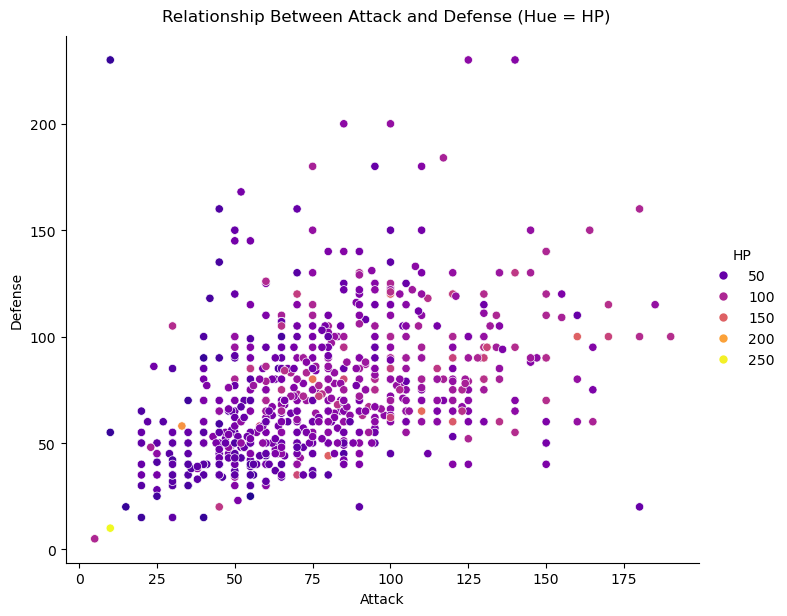

In [7]:
# Your code here . . .

df = pd.read_csv(fp)
g = sns.relplot(
    data=df,
    x="Attack",
    y="Defense",
    hue="HP",
    palette="plasma",
    height=6,
    aspect=1.2
)

g.fig.suptitle("Relationship Between Attack and Defense (Hue = HP)", y=1.02)
plt.show()

## Q2: Plot the relationship between Attack and Total using a hexbin plot
Create a hexbin plot using seaborn's `joinplot` function. Plot `Attack` on the x-axis and `Total` on the y-axis. You can choose the gridsize. Include a title for the plot "Attack vs total for all Pokemon". After generating the plot, insert a markdown cell to answer this question: The hexbin plot displays the relationship between `Attack` and `Total`, what else does this plot show?

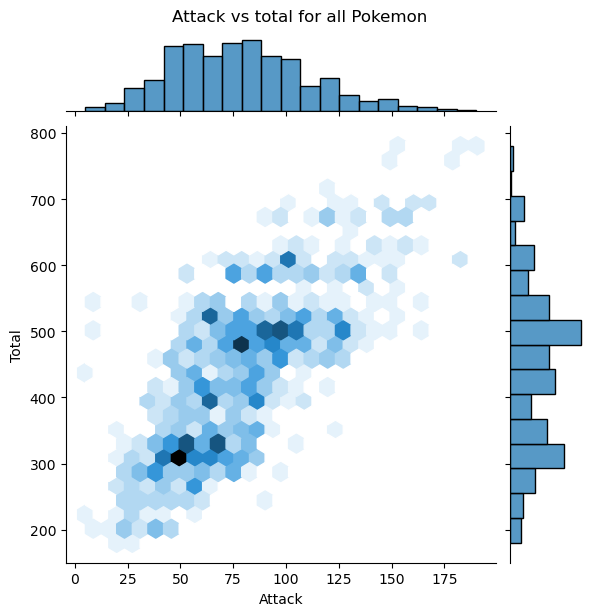

In [8]:
# Your code here . . .
g = sns.jointplot(
    data=df,
    x="Attack",
    y="Total",
    kind="hex",
    gridsize=25
)

g.fig.suptitle("Attack vs total for all Pokemon", y=1.02)
plt.show()

From the plot, I observed....

## Q3: Create two categorical plots for Pokemon types. `Type 1` and `Type 2` .
For each plot, the unique values of `Type 1` or `Type 2` should be plotted along the y-axis, and the counts of Pokemon should be on the x-axis. Use the color red for the `Type 1` plot and blue for the `Type 2` plot. After the two plots are displayed, insert a markdown cell to write your findings: Which are the most common `Type 1` and `Type 2` Pokemons, and which are the most rare ones?

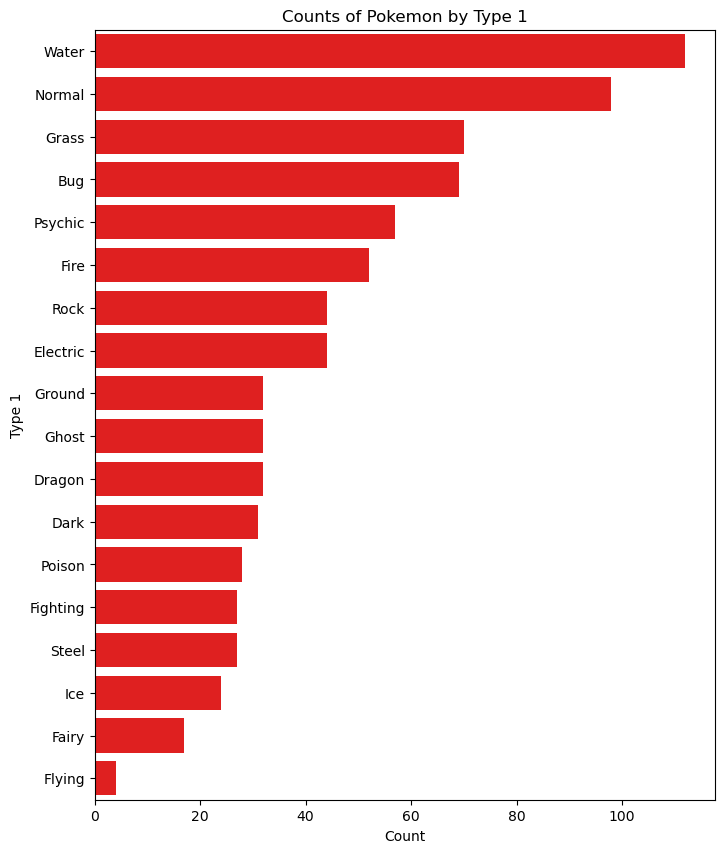

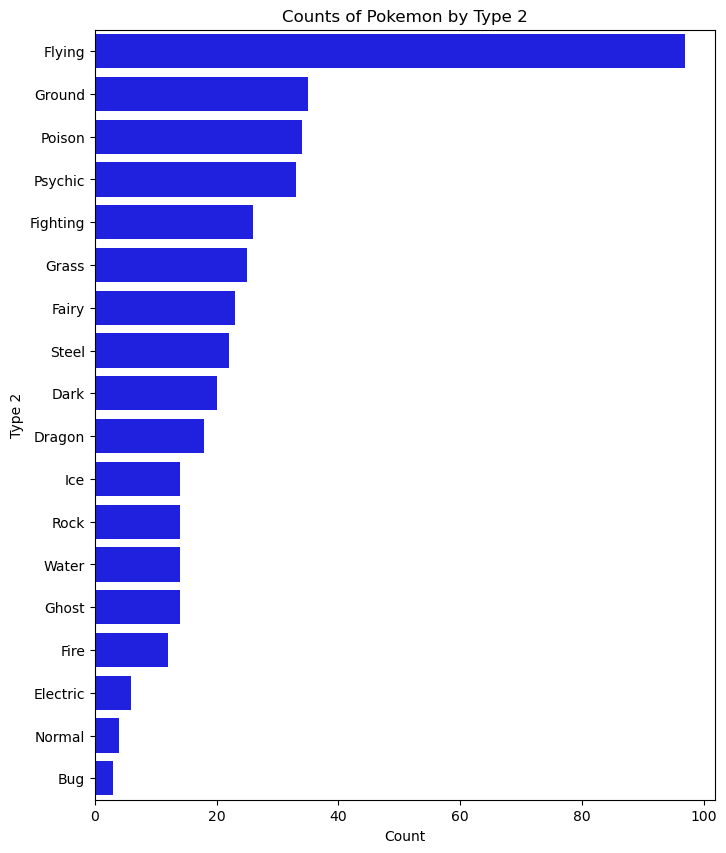

In [9]:
# Your code here . . .

#Type 1
plt.figure(figsize=(8, 10))
order_t1 = df["Type 1"].value_counts().index
sns.countplot(data=df, y="Type 1", order=order_t1, color="red")
plt.title("Counts of Pokemon by Type 1")
plt.xlabel("Count")
plt.ylabel("Type 1")
plt.show()

#Type 2
plt.figure(figsize=(8, 10))
order_t2 = df["Type 2"].dropna().value_counts().index
sns.countplot(data=df.dropna(subset=["Type 2"]), y="Type 2", order=order_t2, color="blue")
plt.title("Counts of Pokemon by Type 2")
plt.xlabel("Count")
plt.ylabel("Type 2")
plt.show()

## Q4-6: Your own question
Come up with three more questions to further explore the pokemon dataset.

Your question(s) . . .

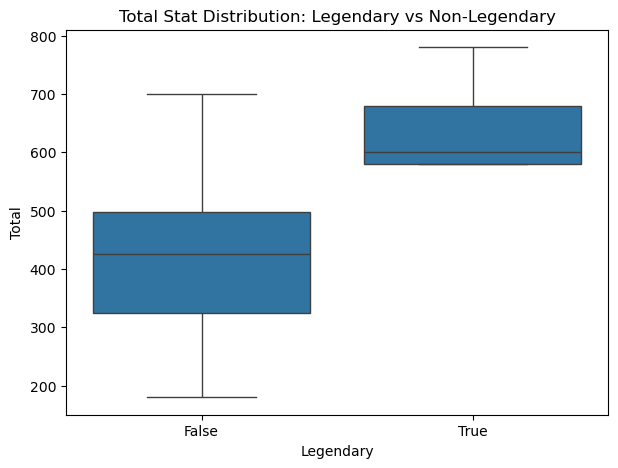

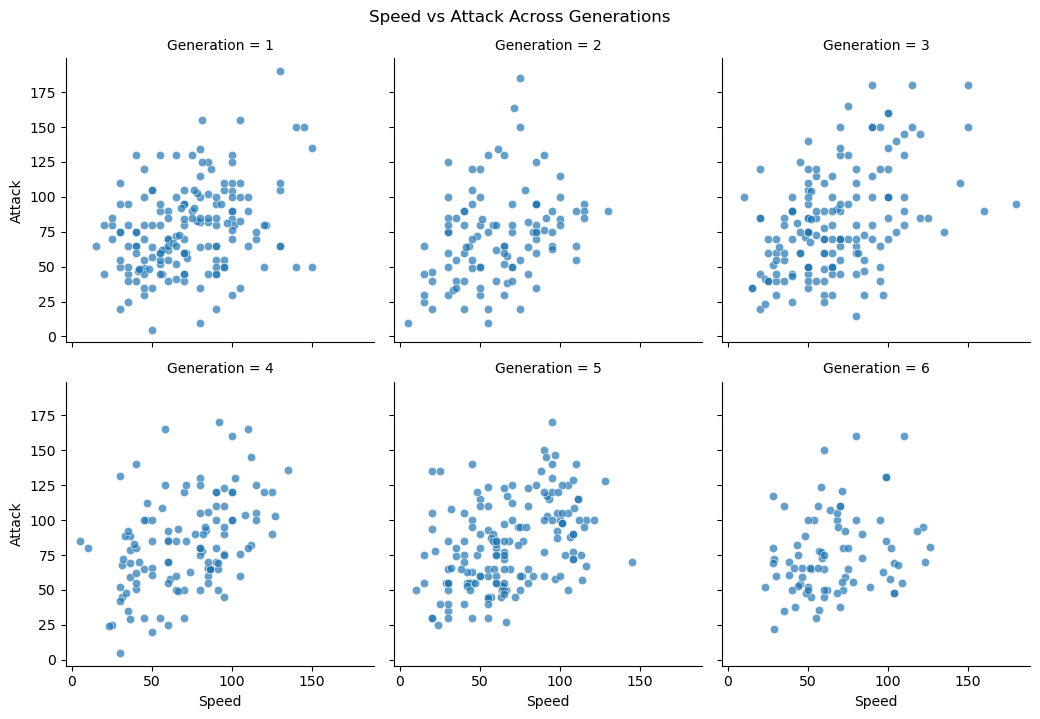

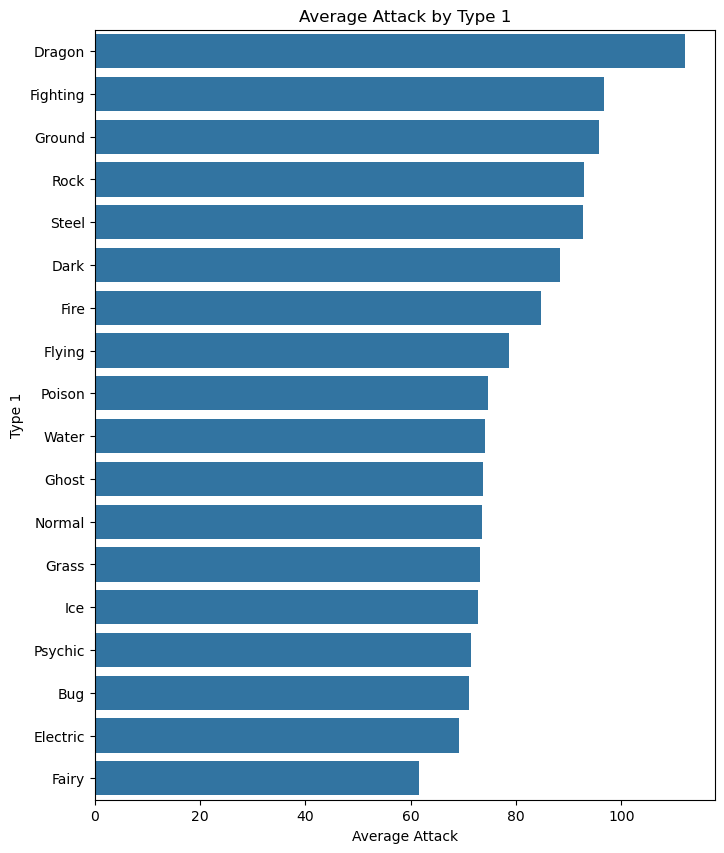

In [10]:
# Your code here . . .

#Q4 Do Legendary pokemon have higher total stats
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Legendary", y="Total")
plt.title("Total Stat Distribution: Legendary vs Non-Legendary")
plt.show()

#Q5 Do SPeed and Attack change over generation
g = sns.relplot(
    data=df,
    x="Speed",
    y="Attack",
    col="Generation",
    col_wrap=3,
    height=3.5,
    alpha=0.7
)
g.fig.suptitle("Speed vs Attack Across Generations", y=1.02)
plt.show()

#Q6 Which type 1 has the highest average attack
type_attack = (
    df.groupby("Type 1")["Attack"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 10))
sns.barplot(x=type_attack.values, y=type_attack.index)
plt.title("Average Attack by Type 1")
plt.xlabel("Average Attack")
plt.ylabel("Type 1")
plt.show()